In [1]:
import pandas as pd 
import matplotlib.pyplot as plt 
import  numpy as np 
%matplotlib inline 

In [3]:
df = pd.read_csv('height-weight.csv')
df

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160
5,78,162
6,80,163
7,90,175
8,95,182
9,78,170


Text(0, 0.5, 'Height')

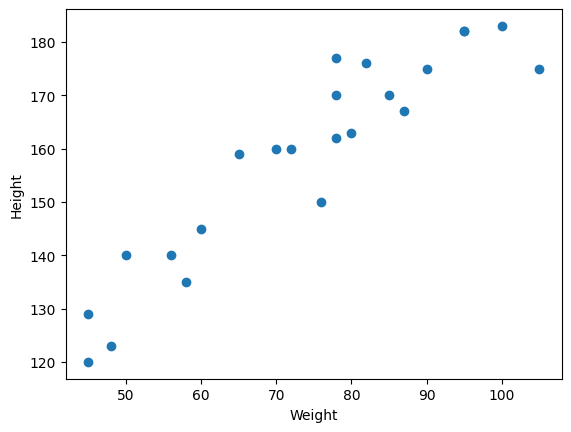

In [4]:
plt.scatter(df['Weight'] , df['Height'])
plt.xlabel('Weight')
plt.ylabel("Height")

In [10]:
## our main aim is to create a best fit line 

X = df[['Weight']]  ## independent feature  
y = df['Height']  ## dependent feature 

In [11]:
from sklearn.model_selection import train_test_split 
X_train , X_test , y_train , y_test  = train_test_split(X , y ,test_size=0.20 , random_state=42)

In [12]:
X.shape

(23, 1)

In [13]:
X_train.shape , X_test.shape , y_train.shape  , y_test.shape

((18, 1), (5, 1), (18,), (5,))

In [15]:
## standardising the independent data 

from sklearn.preprocessing import StandardScaler 
scalar = StandardScaler() 
X_train = scalar.fit_transform(X_train)

In [17]:
X_test = scalar.transform(X_test)     
### transform will not use the mean and varience of this test data it will use that of train only 

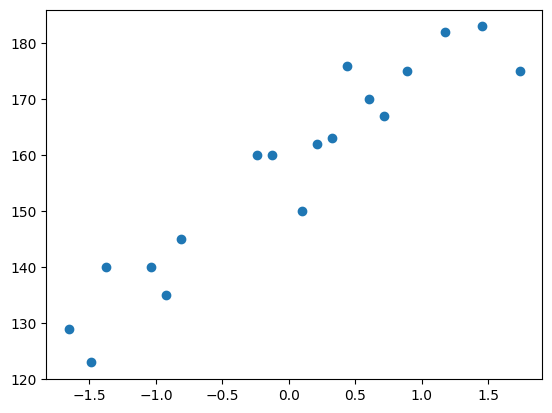

In [18]:
plt.scatter(X_train , y_train)

In [19]:
## train the model 

from sklearn.linear_model import  LinearRegression
regression = LinearRegression(n_jobs=-1)

In [21]:
regression.fit(X_train , y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,-1
,positive,False


In [22]:
print("Coefficient or slope  is : " ,regression.coef_)
print("Intercept  :" , regression.intercept_)

Coefficient or slope  is :  [17.03440872]
Intercept  : 157.5


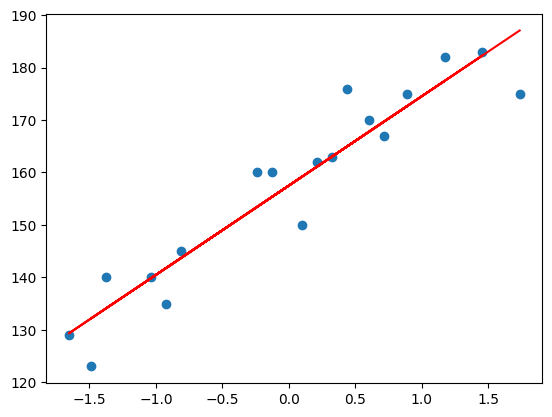

In [23]:
plt.scatter(X_train , y_train)
plt.plot(X_train , regression.predict(X_train),'red')

In [24]:
y_pred=regression.predict(X_test)

In [25]:
y_test , y_pred

(15    177
 9     170
 0     120
 8     182
 17    159
 Name: Height, dtype: int64,
 array([161.08467086, 161.08467086, 129.3041561 , 177.45645118,
        148.56507414]))

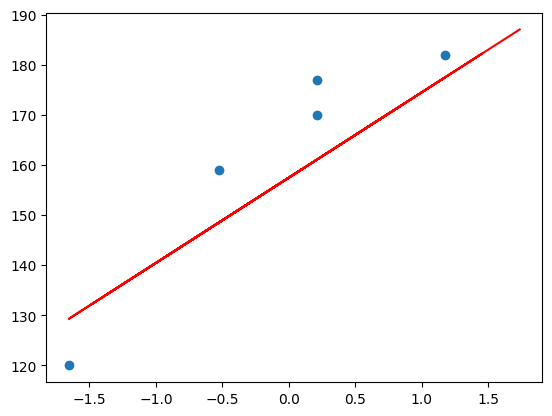

In [27]:
plt.scatter(X_test , y_test)
plt.plot(X_train , regression.predict(X_train) , 'r')

In [29]:

from sklearn.metrics import mean_absolute_error, mean_squared_error

mse=mean_squared_error(y_test , y_pred)
mae=mean_absolute_error(y_test , y_pred)
rmse=np.sqrt(mse)

print(mse)
print(mae)
print(rmse)

109.77592599051664
9.822657814519232
10.477400726827081


## r Square 

r^2 = 1- ssr(sum of square of residues)/sst(total sum of squares)
 

In [30]:
from sklearn.metrics import r2_score
score = r2_score(y_test  , y_pred)
print (score)

0.776986986042344


In [31]:
scaled_weight = scalar.transform([[80]])
scaled_weight

c:\Users\saura\OneDrive\Desktop\VS CODE FILES\python ml\venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([[0.32350772]])

In [32]:
regression.predict(scalar.transform([[80]]))

c:\Users\saura\OneDrive\Desktop\VS CODE FILES\python ml\venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([163.01076266])

In [40]:
def get_height(w , regression):
    return regression.predict(scalar.transform([[w]]))[0]


In [42]:
get_height(80, regression)

c:\Users\saura\OneDrive\Desktop\VS CODE FILES\python ml\venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


np.float64(163.01076265919562)